# Polynomial Regression on California Housing Dataset

In this notebook, we will:
- load and inspect the dataset
- handle missing values
- encode categorical data
- create new features
- remove extreme outliers
- split the data into train and test sets
- scale the features
- train a Linear Regression baseline
- train a Polynomial Regression model
- compare both models

## Importing Required Libraries

In [784]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## Load Dataset 
The target variable is `median_house_value`.

In [785]:
df = pd.read_csv('housing.csv')
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


## Basic Data Inspection

In [786]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


In [787]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


## Check Missing Values and Duplicate Rows

In [788]:
print("Null Values :")
print(df.isnull().sum())
print("Duplicate Rows :", df.duplicated().sum())

Null Values :
longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64
Duplicate Rows : 0


## Handle Missing Values

`total_bedrooms` has missing values, so we fill them using the median.
The median is a safe choice because it is less affected by outliers.

In [789]:
df["total_bedrooms"] = df["total_bedrooms"].fillna(
    df["total_bedrooms"].median()
)

## Check the Categorical Column

`ocean_proximity` is a categorical feature.
Before training regression models, we must convert it into numeric columns using one-hot encoding.

In [790]:
df["ocean_proximity"].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

## One-Hot Encode `ocean_proximity`

We use one-hot encoding to convert categories into numeric form.

`drop_first=True` helps avoid the dummy variable trap by removing one category as the baseline.

In [791]:
df = pd.get_dummies(
    df,
    columns=["ocean_proximity"],
    drop_first=True,
    dtype=int
)

In [792]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,0,0,1,0
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,0,0,1,0
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,0,0,1,0
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,0,0,1,0
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,0,0,1,0


## Correlation Matrix

This heatmap helps us understand:
- which features are strongly related to the target
- which features are strongly related to each other
- possible multicollinearity

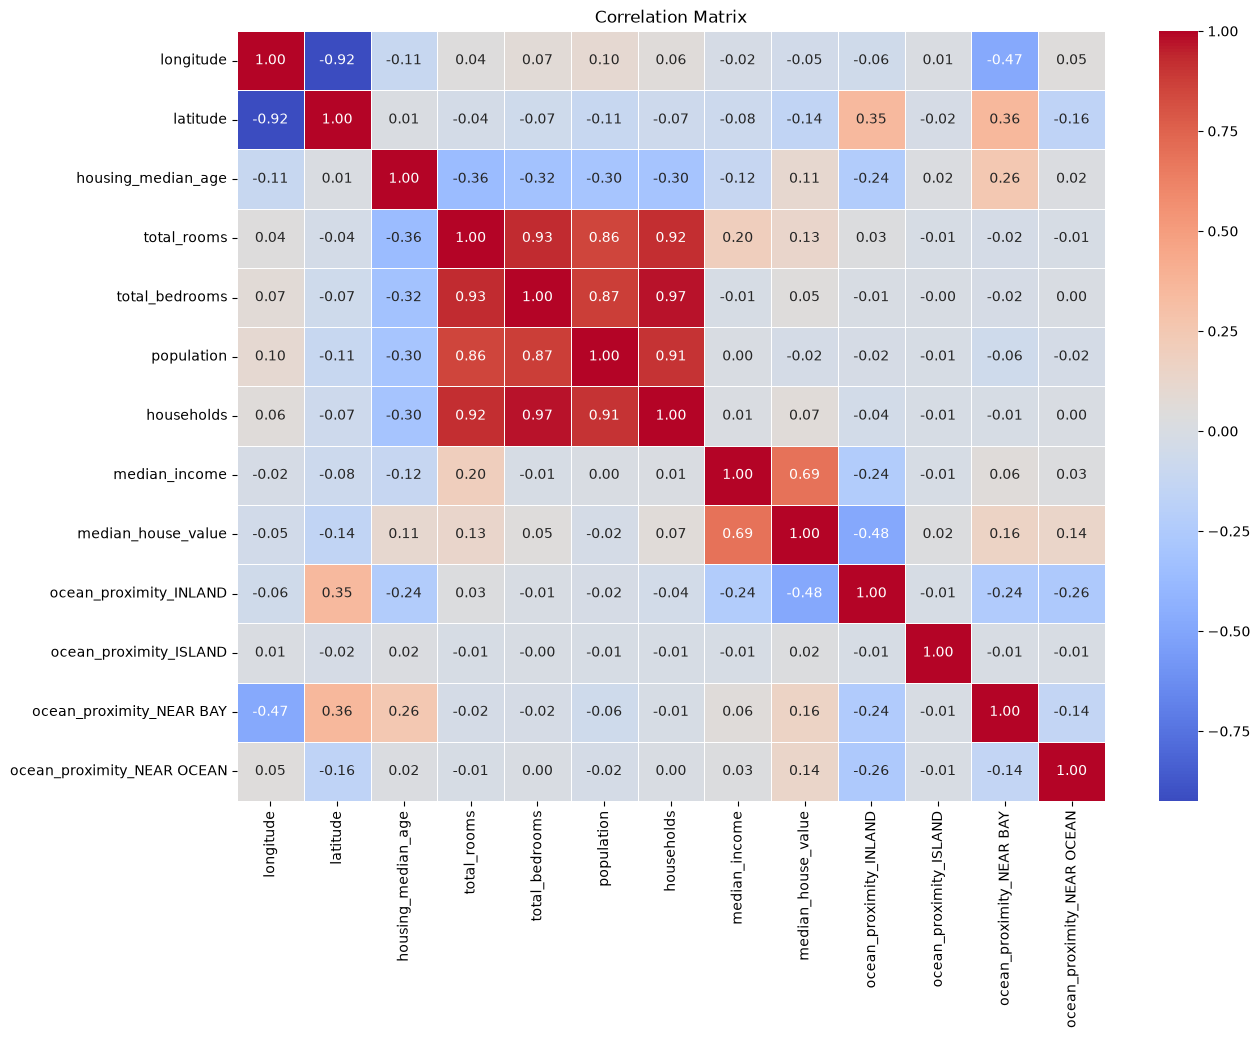

In [793]:
plt.figure(figsize=(14,10))

sns.heatmap(
    df.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Matrix")
plt.show()

## Feature Engineering

We create better features from the raw counts:

- `rooms_per_household`
- `population_per_household`
- `bedrooms_per_room`

These features often capture the structure of a neighborhood better than raw counts.

In [794]:
df["rooms_per_household"] = df["total_rooms"] / df["households"]
df["population_per_household"] = df["population"] / df["households"]
df["bedrooms_per_room"] = df["total_bedrooms"] / df["total_rooms"]

## Remove Redundant Raw Columns

After creating ratio features, we remove the original count columns to reduce multicollinearity.

In [795]:
df = df.drop(
    columns=[
        "total_rooms",
        "population",
        "total_bedrooms"
    ]
)

## Correlation Matrix After Feature Engineering

Now we check whether the new features behave better and whether the strongest correlations with the target become clearer.

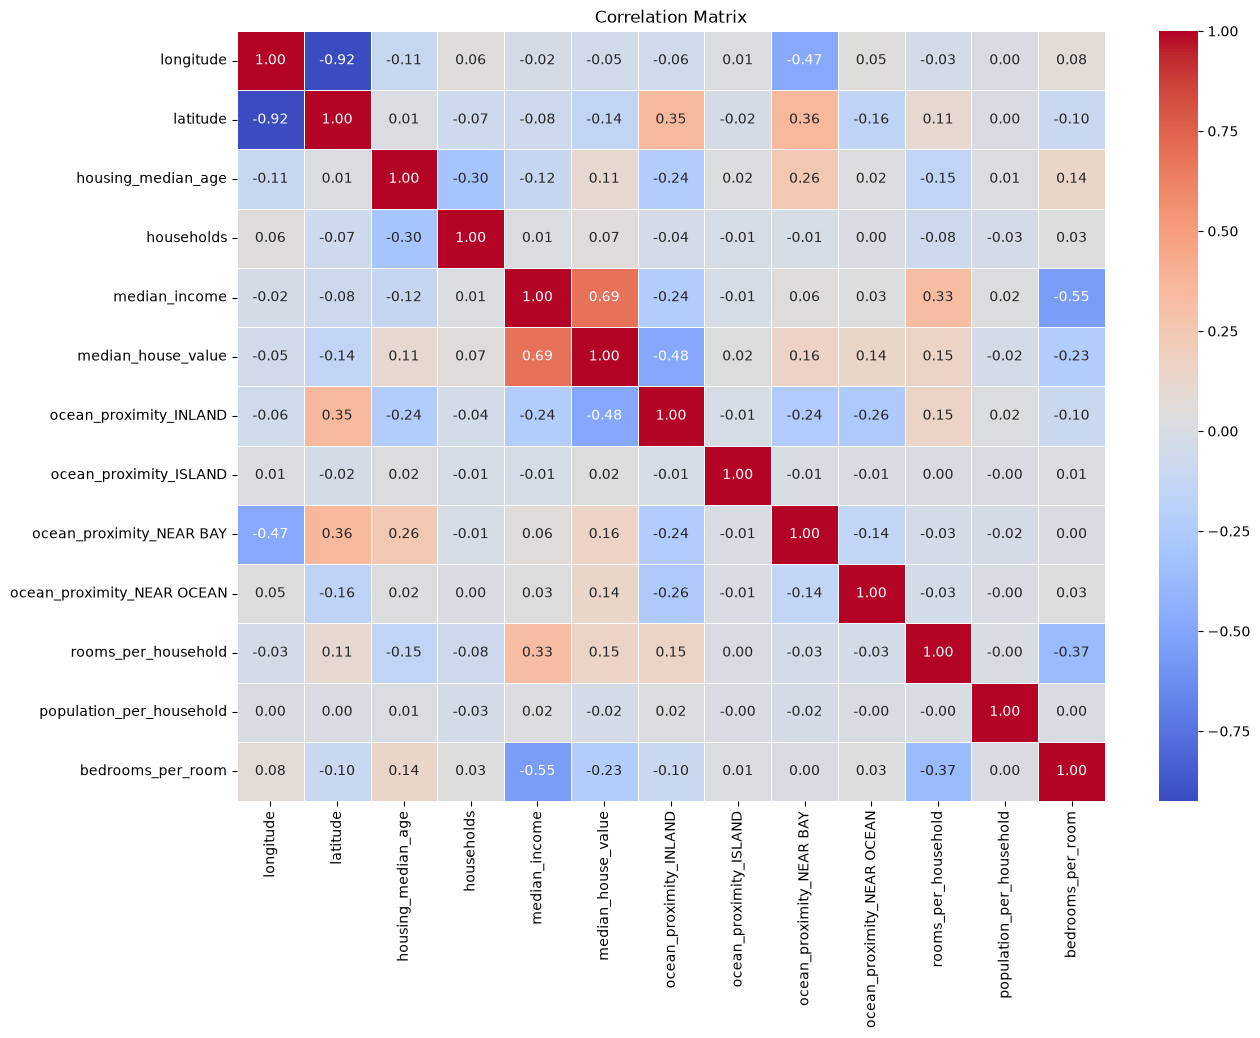

In [796]:
plt.figure(figsize=(14,10))

sns.heatmap(
    df.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Matrix")
plt.show()

## Distribution of Engineered Features

We inspect the distributions of the new features to see whether they are skewed or contain extreme values.

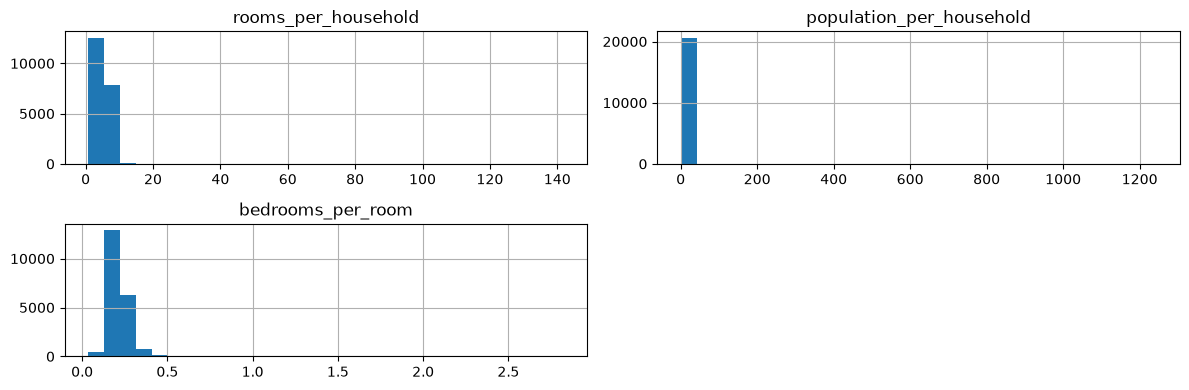

In [797]:
new_features = [
    "rooms_per_household",
    "population_per_household",
    "bedrooms_per_room"
]

df[new_features].hist(figsize=(12,4), bins=30)

plt.tight_layout()
plt.show()

## Handle Extreme Outliers

Some engineered features contain very large values that are not realistic.
We remove those extreme outliers to make the dataset cleaner for training.

In [798]:
df[df["population_per_household"] > 20]

,longitude,latitude,housing_median_age,households,median_income,median_house_value,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN,rooms_per_household,population_per_household,bedrooms_per_room
3364,-120.51,40.41,36.0,7.0,5.5179,67500.0,1,0,0,0,5.142857,599.714286,0.222222
5986,-117.71,34.10,52.0,126.0,1.8750,212500.0,1,0,0,0,4.500000,21.333333,0.268078
8874,-118.45,34.06,52.0,28.0,9.3370,500001.0,0,0,0,0,7.285714,41.214286,0.166667
9172,-118.59,34.47,5.0,105.0,4.2391,154600.0,1,0,0,0,5.123810,83.171429,0.182156
12104,-117.33,33.97,8.0,20.0,1.6250,162500.0,1,0,0,0,7.600000,63.750000,0.125000
13034,-121.15,38.69,52.0,29.0,6.1359,225000.0,1,0,0,0,8.275862,230.172414,0.183333
13366,-117.63,33.94,36.0,85.0,4.2578,183300.0,1,0,0,0,5.258824,33.952941,0.212528
16420,-121.29,37.89,26.0,30.0,5.7485,162500.0,1,0,0,0,5.366667,51.400000,0.167702
16669,-120.70,35.32,46.0,13.0,4.2639,350000.0,0,0,0,1,9.076923,502.461538,0.144068
19006,-121.98,38.32,45.0,6.0,10.2264,137500.0,1,0,0,0,3.166667,1243.333333,0.263158


In [799]:
df = df[df["population_per_household"] < 20]
df = df[df["rooms_per_household"] < 20]

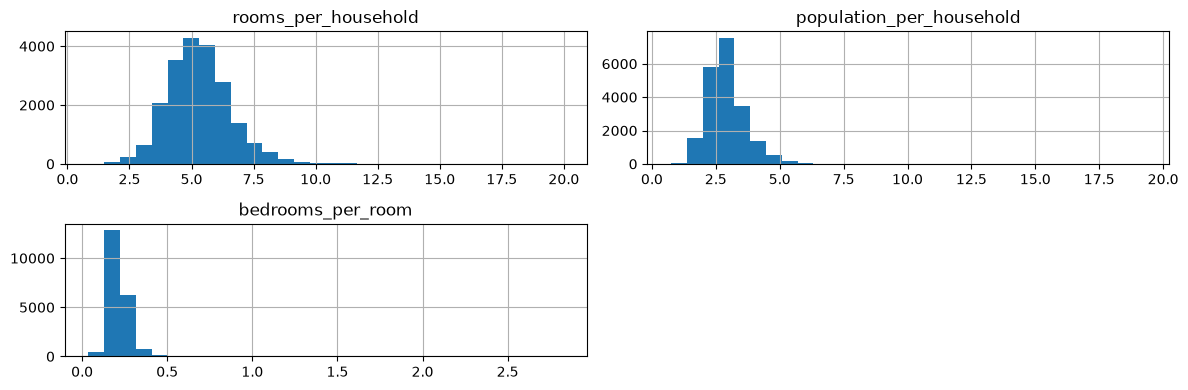

In [800]:
new_features = [
    "rooms_per_household",
    "population_per_household",
    "bedrooms_per_room"
]

df[new_features].hist(figsize=(12,4), bins=30)

plt.tight_layout()
plt.show()

## Target Distribution

We visualize the target variable to understand its shape.

This dataset is known to have a spike near the upper limit because house values were capped in the original dataset.

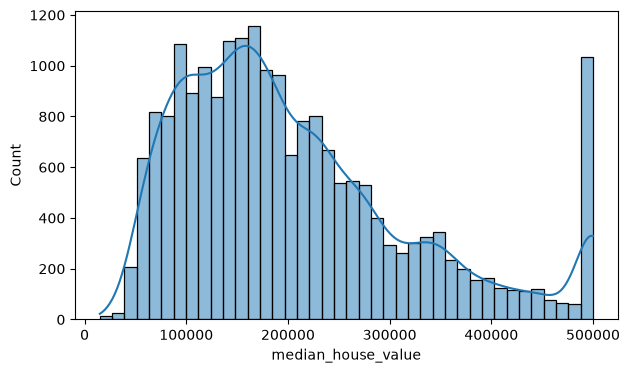

In [801]:
plt.figure(figsize=(7,4))

sns.histplot(
    df["median_house_value"],
    bins=40,
    kde=True
)

plt.show()

## Separate Features and Target

`X` contains the input features.

`y` contains the target variable we want to predict.

In [802]:
X = df.drop("median_house_value", axis=1)

y = df["median_house_value"]

## Train-Test Split

We split the data into:
- training set: used to train the model
- test set: used only for evaluation

`random_state=42` makes the split reproducible.

In [803]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

## Feature Scaling

We scale the input features so that all of them are on a similar scale.

This is especially important for Polynomial Regression because polynomial expansion can create very large feature values.

In [804]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

In [805]:
X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=X_train.columns
)

X_train_scaled.head()

,longitude,latitude,housing_median_age,households,median_income,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN,rooms_per_household,population_per_household,bedrooms_per_room
7674,0.745059,-0.805447,0.586396,-0.151955,0.431572,-0.674772,-0.017438,-0.354906,-0.385179,0.018626,0.959080,-0.572861
12465,-0.916838,1.371207,1.382467,-0.117928,-0.150557,1.481981,-0.017438,-0.354906,-0.385179,0.006706,-1.021150,-0.286431
3322,-1.618417,1.563127,-0.607711,-0.848198,-1.132608,1.481981,-0.017438,-0.354906,-0.385179,-0.043044,0.220794,-0.398917
13021,-0.817323,1.436740,-0.846532,0.452678,0.513826,1.481981,-0.017438,-0.354906,-0.385179,1.407133,0.424897,-1.053332
5557,0.585835,-0.796085,1.302860,-0.301150,0.452530,-0.674772,-0.017438,-0.354906,-0.385179,-0.049492,-0.147986,-0.309442


In [806]:
print(X_train_scaled.mean())

longitude                    -3.461131e-15
latitude                      2.228222e-15
housing_median_age           -7.257489e-17
households                   -6.652698e-17
median_income                -9.115061e-17
ocean_proximity_INLAND        2.116768e-17
ocean_proximity_ISLAND        0.000000e+00
ocean_proximity_NEAR BAY     -2.764758e-17
ocean_proximity_NEAR OCEAN   -7.948678e-17
rooms_per_household           3.067153e-17
population_per_household      5.460397e-16
bedrooms_per_room             3.196751e-16
dtype: float64


## Baseline Model: Linear Regression

We first train a simple Linear Regression model.

This gives us a baseline to compare with Polynomial Regression later.

In [807]:
from sklearn.linear_model import LinearRegression
linear_model = LinearRegression()

In [808]:
linear_model.fit(X_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](12,)","[-56331.36,-58586.91, 12225.45,..., 5355.02,-22313.27, 12254.66]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](12,)","['longitude','latitude','housing_median_age',...,'rooms_per_household', 'population_per_household','bedrooms_per_room']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2.07e+05
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,12
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,12


## Evaluate the Baseline Model

We use:
- R² Score
- MAE
- MSE
- RMSE

These metrics tell us how well the Linear Regression model performs.

In [809]:
y_pred = linear_model.predict(X_test_scaled)

In [810]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f"R² Score : {r2:.4f}")
print(f"MAE      : {mae:.2f}")
print(f"MSE      : {mse:.2f}")
print(f"RMSE     : {rmse:.2f}")

R² Score : 0.6530
MAE      : 49011.97
MSE      : 4733287495.02
RMSE     : 68798.89


## Actual vs Predicted Plot

If the points are close to the red line, the model is performing well.

The farther the points are from the red line, the larger the prediction error.

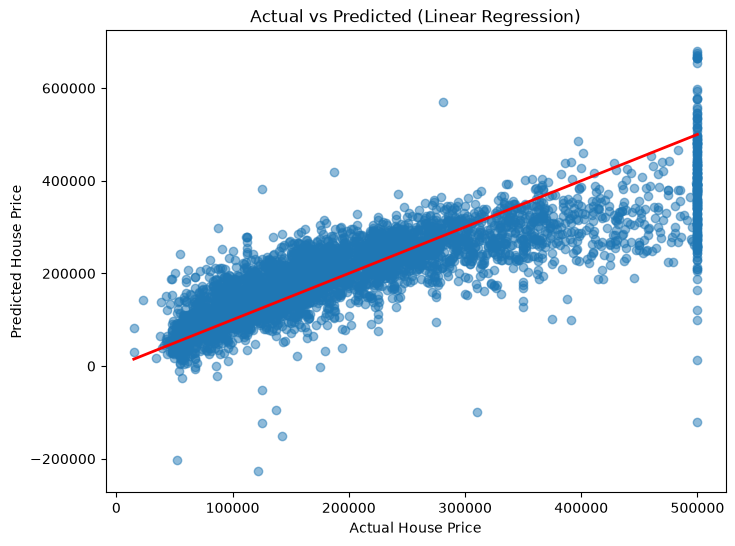

In [811]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred, alpha=0.5)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linewidth=2
)

plt.xlabel("Actual House Price")
plt.ylabel("Predicted House Price")
plt.title("Actual vs Predicted (Linear Regression)")

plt.show()

## Polynomial Features

We now expand the feature space using Polynomial Features.

This creates:
- squared terms
- interaction terms
- cubic terms

This allows the model to learn more complex relationships.

In [812]:
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(
    degree=3,
    include_bias=False
)

In [813]:
X_train_poly = poly.fit_transform(X_train_scaled)

X_test_poly = poly.transform(X_test_scaled)

## Train Polynomial Regression

Polynomial Regression is still Linear Regression underneath.
The difference is that we train it on polynomial-expanded features.

In [814]:
poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](454,)","[-12142.8 , -7905.84, 56.74,..., 59.52, 266.79, 60.89]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2.529e+05
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,454
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,302
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](454,)","[422046.32, 64857.68, 14028.58,..., 0. , 0. , 0. ]"


In [815]:
y_pred_poly = poly_model.predict(X_test_poly)

## Evaluate Polynomial Regression

Now we check whether polynomial features improved the model over the baseline Linear Regression.

In [816]:
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error,
)

r2_poly = r2_score(y_test, y_pred_poly)
mae_poly = mean_absolute_error(y_test, y_pred_poly)
mse_poly = mean_squared_error(y_test, y_pred_poly)
rmse_poly = np.sqrt(mse_poly)

print(f"R² Score : {r2_poly:.4f}")
print(f"MAE      : {mae_poly:.2f}")
print(f"MSE      : {mse_poly:.2f}")
print(f"RMSE     : {rmse_poly:.2f}")

R² Score : 0.7410
MAE      : 38699.79
MSE      : 3533063049.63
RMSE     : 59439.57


## Model Comparison

We compare Linear Regression and Polynomial Regression using the same evaluation metrics.

The better model should have:
- higher R²
- lower MAE
- lower RMSE

In [817]:
comparison = pd.DataFrame({
    "Metric": ["R²", "MAE", "RMSE"],
    "Linear Regression": [r2, mae, rmse],
    "Polynomial Regression": [r2_poly, mae_poly, rmse_poly]
})

comparison

,Metric,Linear Regression,Polynomial Regression
0,R²,0.652995,0.740986
1,MAE,49011.971832,38699.787136
2,RMSE,68798.891670,59439.574777


## Overfitting Check

We compare training R² and testing R².

If training R² is much higher than testing R², the model may be overfitting.

In [818]:
# Training predictions
y_train_pred_poly = poly_model.predict(X_train_poly)

# Training R²
train_r2 = r2_score(y_train, y_train_pred_poly)

# Testing R²
test_r2 = r2_score(y_test, y_pred_poly)

print(f"Training R² : {train_r2:.4f}")
print(f"Testing R²  : {test_r2:.4f}")

Training R² : 0.7865
Testing R²  : 0.7410


## Conclusion

In this notebook, we:
- cleaned the dataset
- encoded categorical data
- created new features
- removed outliers
- trained a baseline Linear Regression model
- trained a Polynomial Regression model
- compared the results

Polynomial Regression performed better than Linear Regression on this dataset.